# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('/Users/malasri/Desktop/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [ ]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


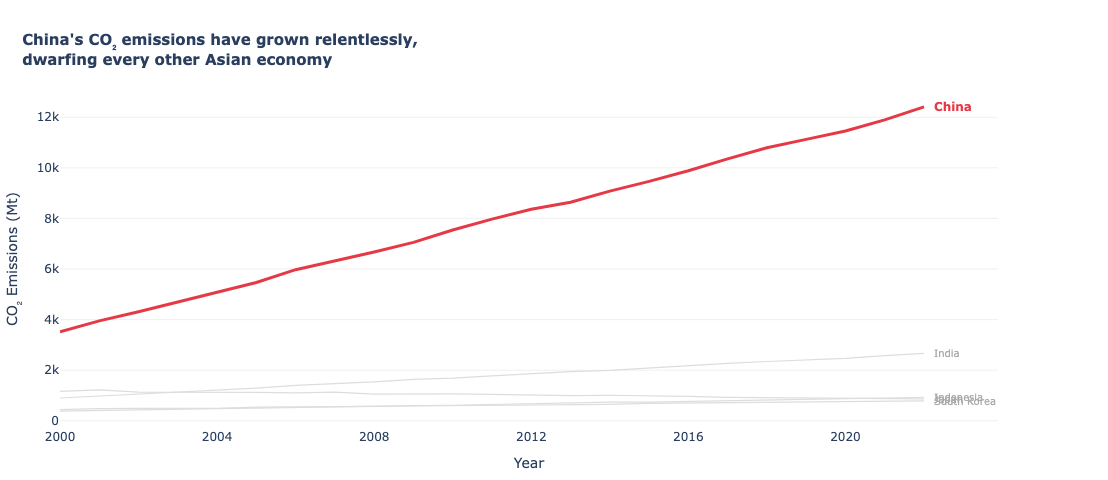

In [ ]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
asia_df = df[df["Region"] == "Asia"]
HIGHLIGHT = "China"
HIGHLIGHT_COLOR = "#E63946"
GREY = "#DDDDDD"
 
fig1 = go.Figure()
 
for country, grp in asia_df.groupby("Country"):
    grp = grp.sort_values("Year")
 
    if country == HIGHLIGHT:
        # Highlighted line
        fig1.add_trace(go.Scatter(
            x=grp["Year"],
            y=grp["CO2_Mt"],
            mode="lines",
            name=country,
            line=dict(color=HIGHLIGHT_COLOR, width=3),
            showlegend=False,
        ))
        # Direct end-of-line label
        fig1.add_annotation(
            x=grp["Year"].iloc[-1],
            y=grp["CO2_Mt"].iloc[-1],
            text=f"<b>{country}</b>",
            xanchor="left",
            xshift=8,
            showarrow=False,
            font=dict(color=HIGHLIGHT_COLOR, size=12),
        )
    else:
        # Background lines
        fig1.add_trace(go.Scatter(
            x=grp["Year"],
            y=grp["CO2_Mt"],
            mode="lines",
            name=country,
            line=dict(color=GREY, width=1.2),
            showlegend=False,
        ))
        # Subtle grey labels for context
        fig1.add_annotation(
            x=grp["Year"].iloc[-1],
            y=grp["CO2_Mt"].iloc[-1],
            text=country,
            xanchor="left",
            xshift=8,
            showarrow=False,
            font=dict(color="#AAAAAA", size=10),
        )
 
fig1.update_layout(
    title=dict(
        text="<b>China's CO₂ emissions have grown relentlessly,<br>"
             "dwarfing every other Asian economy</b>",
        font=dict(size=15),
        x=0.02,
        xanchor="left",
    ),
    xaxis=dict(title="Year", showgrid=False, tickmode="linear", dtick=4),
    yaxis=dict(title="CO₂ Emissions (Mt)", showgrid=True,
               gridcolor="#F0F0F0", zeroline=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(r=110, t=90, l=60, b=50),
    width=820,
    height=480,
)
 
fig1.show()
# fig1.write_image("task1_asia_lines.png", scale=2)   # uncomment to export

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


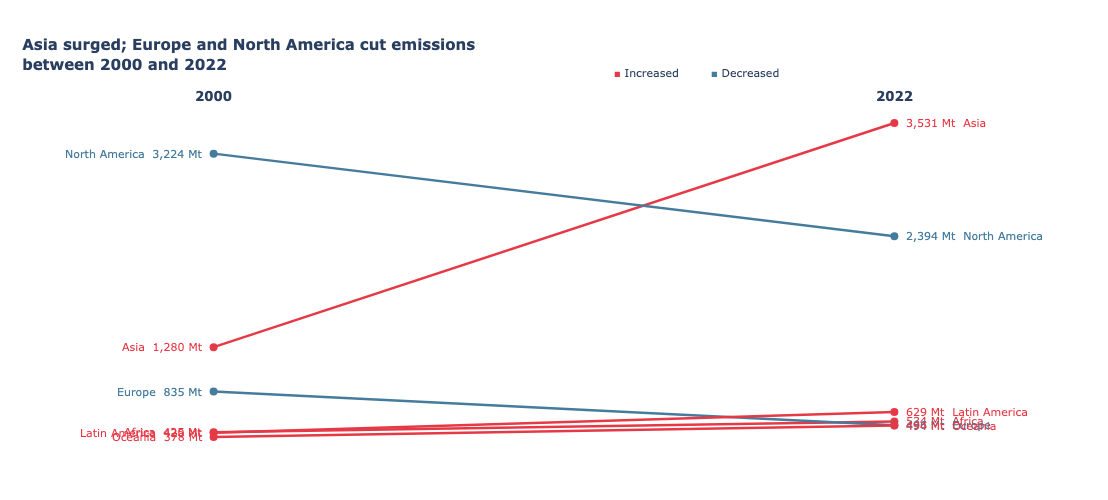

In [ ]:
regional = (
    df.groupby(["Region", "Year"])["CO2_Mt"]
    .mean()
    .reset_index()
)
 
start = regional[regional["Year"] == 2000].set_index("Region")["CO2_Mt"]
end   = regional[regional["Year"] == 2022].set_index("Region")["CO2_Mt"]
regions = start.index.tolist()
 
INCREASE_COLOR = "#E63946"   # red  → grew
DECREASE_COLOR = "#457B9D"   # blue → shrank
 
fig2 = go.Figure()
 
for region in regions:
    y0, y1 = start[region], end[region]
    color = INCREASE_COLOR if y1 >= y0 else DECREASE_COLOR
 
    # Slope line
    fig2.add_trace(go.Scatter(
        x=[0, 1],
        y=[y0, y1],
        mode="lines+markers",
        line=dict(color=color, width=2.5),
        marker=dict(size=8, color=color),
        showlegend=False,
    ))
 
    # Left label  (2000)
    fig2.add_annotation(
        x=0, y=y0,
        text=f"{region}  {y0:,.0f} Mt",
        xanchor="right",
        xshift=-10,
        showarrow=False,
        font=dict(color=color, size=11),
    )
 
    # Right label (2022)
    fig2.add_annotation(
        x=1, y=y1,
        text=f"{y1:,.0f} Mt  {region}",
        xanchor="left",
        xshift=10,
        showarrow=False,
        font=dict(color=color, size=11),
    )
 
# Year axis labels
fig2.add_annotation(x=0, y=1.04, yref="paper",
                    text="<b>2000</b>", showarrow=False,
                    font=dict(size=13), xanchor="center")
fig2.add_annotation(x=1, y=1.04, yref="paper",
                    text="<b>2022</b>", showarrow=False,
                    font=dict(size=13), xanchor="center")
 
# Colour legend chips
for label, color, xpos in [("Increased", INCREASE_COLOR, 0.68),
                            ("Decreased", DECREASE_COLOR, 0.82)]:
    fig2.add_annotation(
        x=xpos, y=1.10, xref="paper", yref="paper",
        text=f"<span style='color:{color}'>■</span> {label}",
        showarrow=False, font=dict(size=11),
    )
 
fig2.update_layout(
    title=dict(
        text="<b>Asia surged; Europe and North America cut emissions<br>"
             "between 2000 and 2022</b>",
        font=dict(size=15),
        x=0.02,
        xanchor="left",
    ),
    xaxis=dict(
        tickvals=[0, 1],
        ticktext=["", ""],   # hidden — annotations carry the labels
        showgrid=False,
        zeroline=False,
        range=[-0.02, 1.02],
    ),
    yaxis=dict(
        showticklabels=False,   # endpoint labels make ticks redundant
        showgrid=False,
        zeroline=False,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=200, r=200, t=100, b=40),
    width=820,
    height=500,
)
 
fig2.show()
# fig2.write_image("task2_slopegraph.png", scale=2)   # uncomment to export
 